# Modelando o voo de uma abelha: uma abordagem computacional ao filme "Bee Movie"

- PET - Física UFRN
- Petiana: Juliana Magalhães Gonçalves
- Data: 19 de junho de 2026

$\quad$ O objetivo deste `Notebook` é analisar a física que rege o voo de uma abelha comum e investigar se um modelo aerodinâmico quasi-estático simples consegue reproduzir a ordem de grandeza das forças que sustentam o voo de uma abelha. Nele, busca-se explorar um dos desafios mais fascinantes da bioaerodinâmica e que foi abordado de maneira lúdica na obra cinematográfica "Bee Movie" (2007). O `Notebook` está organizado da seguinte forma:

1. *Introdução*
2. *Modelo aerodinâmico quasi-estático*
3. *Simulação computacional*
4. *Conclusão*

## Pré-requisitos
$\quad$ A leitura deste `Notebook` não requer demasiado conhecimento prévio sobre a anatomia das abelhas. No entanto, para que o leitor ou a leitora se familiarize um pouco com o assunto, indico fortemente a leitura da referência [1]. Ademais, é interessante ter certo conhecimento prévio sobre física 2 (Introdução a Fluidos e Termodinâmica), cálculo vetorial e diferencial para melhor compreensão.

$\quad$ Além disso, incentivo àqueles que ainda não assistiram ao filme "Bee Movie" que o assistam ao menos uma vez, pois foi nele que surgiu a primeira inspiração para a elaboração deste `Notebook`. :)

### Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Detalhes das bibliotecas

In [2]:
%load_ext version_information
%version_information numpy, matplotlib

Software versions
Python 3.13.3 64bit [GCC 14.2.0]
IPython 9.12.0
OS Linux 6.14.0 37 generic x86_64 with glibc2.41
numpy 2.4.3
matplotlib 3.10.9
Thu Jun 18 15:03:07 2026 -03

## 1. Introdução

> "De acordo com todas as leis conhecidas da aviação, não há como uma abelha ser capaz de voar. Suas asas são muito pequenas para tirar seu corpinho gordo do chão. A abelha, é claro, voa de qualquer maneira porque as abelhas não se importam com o que os humanos acham que é impossível."
> — <cite>Bee Movie (2007)</cite>

$\quad$ O início do filme "Bee Movie" (2007) é marcado por essa fala icônica, que carrega um grande significado atrelado ao interesse histórico de físicos e engenheiros na aerodinâmica do voo das abelhas. Após ler esse trecho uma ou duas vezes, imagino que o leitor ou leitora tenha pensado consigo mesmo(a): "Mas não é óbvio que abelhas não são aviões?". Se esse foi o caso, trata-se de um pensamento absolutamente correto. Abelhas *não são* aviões, tampouco voam da mesma forma que os aviões. Acontece que a fala de abertura da obra cinematográfica está equivocada e, inclusive, tem se mostrado equivocada desde bem antes de o filme ser lançado. Já dizia Michael H. Dickinson em 2005: "Não podemos encolher a asa de um Boeing 747 para o tamanho de uma abelha e esperar que o voo funcione, pois a aerodinâmica é diferente".

$\quad$ A partir disso, vejamos brevemente como funciona o mecanismo de voo das abelhas, majoritariamente regido pelo Vórtice de Zona Frontal (LEV). Mas, antes, vamos definir algumas nomenclaturas importantes para entender os processos e mecanismos físicos do voo das abelhas.

### 1.1. Convenções e terminologia

$\quad$ Para facilitar a compreensão do que será explicado posteriormente, eis a explicação de alguns termos importantes, bem como algumas notações que serão adotadas durante a simulação computacional.

- A **corda da asa** ("*wing chord*") se refere à seção entre as zonas frontal e traseira da asa da abelha ("*leaning edge*" e "*trailing edge*"). A corda da asa de uma abelha mede em torno de 3 mm.
- O **comprimento da asa** ("*wing length*") nada mais é do que a distância entre a base e a ponta da asa. O comprimento da asa de uma abelha mede em torno de 10 mm.

$\quad$ A imagem a seguir representa essas distâncias.

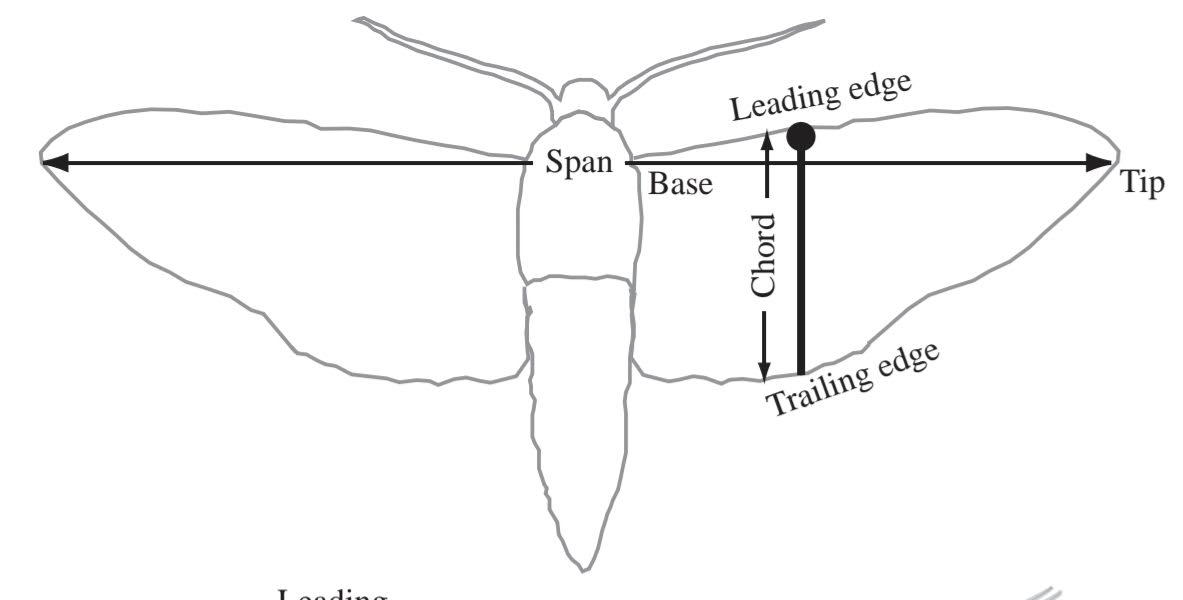

<center> Figura 1: ilustração das dimensões de um inseto (retirada de [3]).

- O **ângulo de ataque** ($\alpha$) se refere à torção da asa sobre o seu próprio eixo longitudinal.
- O **ângulo de varredura** ($\phi$) se refere ao movimento frente-trás das asas.

### 1.2. O Vórtice de Zona Frontal (LEV)

$\quad$ A sigla LEV vem do inglês "Leading Edge Vortex" e diz respeito ao principal mecanismo que permite que uma abelha levante voo. Para estudos mais aprofundados sobre esse mecanismo, é recomendada a leitura da referência [4].

$\quad$ O batimento das asas de uma abelha chega à amplitude de 45 graus em seu ângulo de ataque, o que é bastante alto e faz com que o ar ao redor da borda frontal de cada asa se desprenda. Se as asas de um avião chegassem a essa inclinação, certamente o avião cairia, pois seu movimento é regido pela aerodinâmica estacionária. Felizmente, como já foi mencionado, abelhas não são aviões e voam perfeitamente sob essa condição. Elas batem suas asas com frequência surpreendentemente alta - em torno de 230 vezes por segundo -, de modo que o ar desprendido da zona frontal de cada asa se enrole e forme um vórtice estável. Esse vórtice é o LEV e ele "suga" cada asa para cima, gerando uma sustentação massiva que não existiria se o fluxo de ar ao redor da asa fosse contínuo. O LEV resulta em uma camada de *cisalhamento livre*, que decorre das diferenças de velocidade entre as camadas do ar e é um regime de escoamento característico da aerodinâmica não estacionária.

$\quad$ Ao final de um ciclo, a asa inverte o sentido de seu movimento. Devido à inércia, o fluxo turbulento que ela gerou anteriormente permanece ativo, e, durante a inversão de sentido da asa, a abelha passa por esse fluxo para ganhar sustentação extra em seu voo. Isso é chamado de reaproveitamento ou recuperação de esteira (do inglês ”wake recapture”), que é justamente essa capacidade impressionante das asas de "reaproveitar" essa energia do vórtice (rastro) deixada pelo elemento frontal.

$\quad$ A imagem a seguir (retirada de [1]) ilustra esse mecanismo.

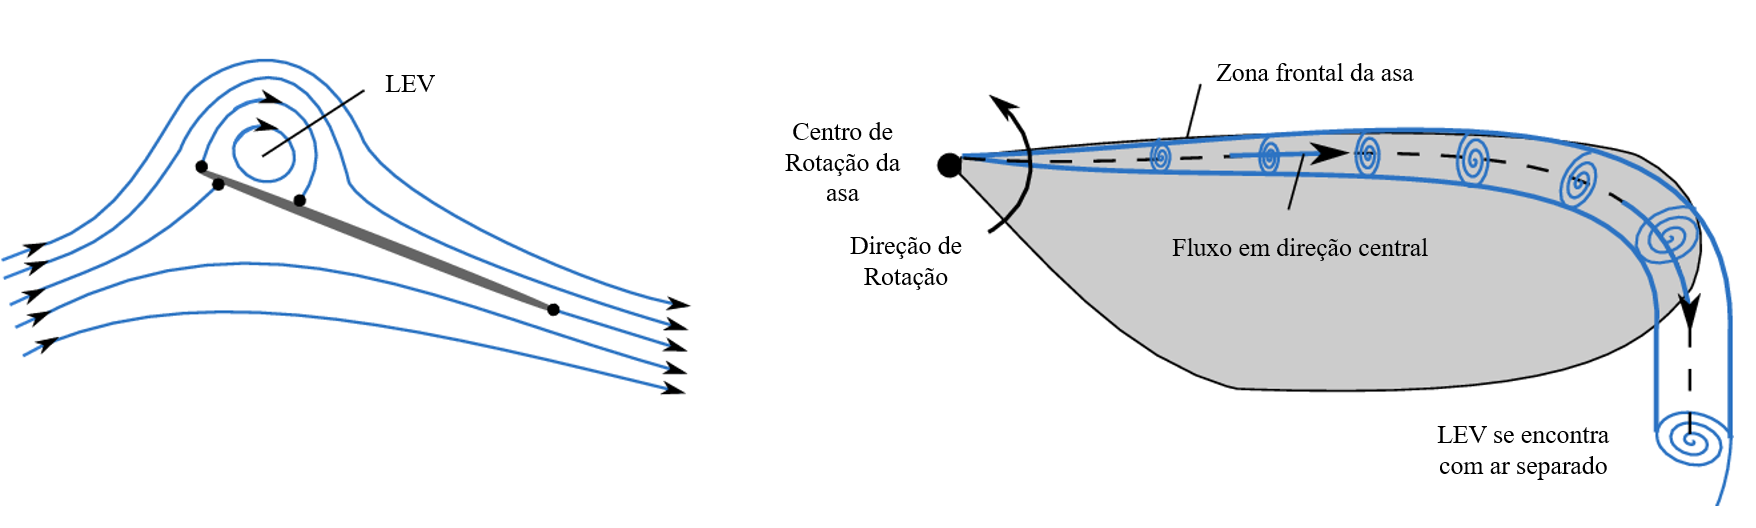

<center>Figura 2: ilustração de um LEV (retirada de [1]).

$\quad$ Exatamente no momento de transição entre a batida para a frente e para trás, a asa realiza uma rotação rápida sobre o seu próprio eixo longitudinal, como se estivesse girando a maçaneta de uma porta. Essa rotação força o ar a girar ao redor da asa. Pelo Princípio de Bernoulli, o ar que gira a favor do fluxo principal se move mais rápido, gerando menor pressão, e o ar que gira contra se move mais devagar (maior pressão). Isso cria uma força de sustentação puramente rotacional no exato momento em que a velocidade de translação da asa é zero.

$\quad$Em suma, o LEV é possível fisicamente porque a abelha opera em um "ponto doce" da mecânica dos fluidos, onde o número de Reynolds ($Re$) está na casa dos 1.000 a 5.000.

### 1.3. Um breve comentário sobre a equação de Navier-Stokes e a mecânica dos fluidos por trás do voo da abelha

$\quad$ O número de Reynolds é expresso pela seguinte equação:

$$
Re = \frac{\rho U_\infty c}{\eta}, \tag{1}
$$

em que $\rho$ é a densidade do fluido-meio (neste caso, o ar), $U_\infty$ é a velocidade do fluido relativa ao objeto em movimento, $c$ é a corda da asa e $\eta$ é a viscosidade do fluido. Esse número é capaz de caracterizar o regime dinâmico no qual um corpo imerso num fluido opera como laminar (para valores baixos de $Re$) ou turbulento (para valores altos de $Re$). No caso do voo da abelha, o valor intermediário de $Re$ é fundamental para que a viscosidade seja apenas o suficiente para manter os vórtices grudados nas asas. 

$\quad$ O número de Reynolds surge na equação de Navier-Stokes em sua forma adimensional:

$$
\begin{equation}
\frac{\partial \hat{u}}{\partial \hat{t}}+(\hat{u}\cdot \hat{\nabla})\hat{u}=-\hat{\nabla}\hat{p}+\frac{1}{Re}\hat{\nabla}^2\hat{u}, \tag{2}
\end{equation}
$$

em que $\hat{u}$ é análogo a $U_\infty$ na equação $(1)$, $\hat{p}$ é a pressão e $\hat{t}$ é o tempo - as demais grandezas são as mesmas da equação $(1)$.

$\quad$O termo $\frac{\partial \hat{u}}{\partial \hat{t}}$ representa como a velocidade do fluido muda em um ponto fixo ao longo do tempo. É como se o ar que envolve a abelha enquanto ela voa "lembrasse" da alta perturbação que sua asa gerou há dois milissegundos. O termo $(\hat{u}\cdot \hat{\nabla}) \hat{u}$ mostra como o próprio movimento do ar transporta o momento linear, e é essa não-linearidade que faz o ar se enrolar e criar o LEV quando a asa bate.

$\quad$Já o lado direito mostra o balanço entre pressão e viscosidade, definindo também, como já foi mencionado, o número de Reynolds. O termo $-\hat{\nabla}\hat{p}$ vem da pressão que empurra a asa para cima e o termo $\hat{\nabla}^2\hat{u}$ vem do atrito do ar que gera o arrasto.

$\quad$Assim, a equação de Navier-Stokes mostra que o voo depende da "memória" do ar, de redemoinhos complexos e de forças viscosas brutas. Discutir a aerodinâmica do voo das abelhas sob a ótica da mecânica dos fluidos é bastante interessante para entender a física real que rege o voo e para fins didáticos. No entanto, de modo geral, essas questões são bastante difíceis para se lidar diretamente em um `Notebook` como este. À vista disso, o modelo desenvolvido neste `Notebook` não resolve diretamente as equações de Navier-Stokes, mas, em vez disso, utiliza aproximações quasi-estáticas que capturam os mecanismos aerodinâmicos dominantes, especialmente o efeito do LEV.

## 2. Modelo aerodinâmico quasi-estático

$\quad$O modelo aerodinâmico quasi-estático é uma alternativa excelente para simular o voo de uma abelha, além de ter a vantagem de ser computacionalmente leve.

$\quad$Para entender o seu conceito, é interessante imaginar a seguinte analogia: se uma abelha for filmada enquanto voa a 240 quadros por segundo e o vídeo for pausado em um único frame, a asa terá uma velocidade e um ângulo específicos naquele exato milésimo de segundo. O modelo quasi-estático assume que, naquele instante isolado, as forças aerodinâmicas agindo na asa são exatamente as mesmas de uma asa estática que estivesse se movendo permanentemente com aquela mesma velocidade e ângulo. Assim, ele transforma um problema dinâmico contínuo e caótico em uma sucessão de fotografias estáticas independentes.

$\quad$Eis algumas hipóteses que o modelo adota:

- Asa rígida;
- Movimento periódico;
- Efeitos tridimensionais negligenciados;
- LEV incorporado via coeficiente de sustentação efetivo;
- Interação entre asas ignorada.

$\quad$Para calcular as forças a cada instante $t$, o modelo utiliza as equações clássicas da aerodinâmica de fluidos, mas tratando as variáveis de movimento como funções do tempo:

$$
\begin{equation}
L(t)=\frac{1}{2}\rho [U(t)]^2SC_L[\alpha(t)], \tag{3}
\end{equation}
$$

$$
\begin{equation}
D(t)=\frac{1}{2}\rho [U(t)]^2SC_D[\alpha(t)], \tag{4}
\end{equation}
$$

onde $L(t)$ é a força de sustentação (*lift force*), $D(t)$ é a força de arrasto (*drag force*), $U(t)$ é a velocidade instantânea da asa, $\alpha(t)$ é o ângulo de ataque instantâneo, $C_L$ e $C_D$ são os coeficientes de sustentação e arrasto, que mudam a cada instante dependendo de $\alpha$. Se aplicássemos o modelo quasi-estático clássico ao voo das abelhas, os coeficientes usados seriam os mesmos da asa de um avião (como já sabemos, isso é um problema).

$\quad$Um elemento essencial do modelo quasi-estático para esse contexto é a **teoria dos elementos de pá** (*blade element theory*). Como a asa da abelha está rotacionando em torno do corpo, a ponta da asa se move muito mais rápido do que a base. Para corrigir isso, o modelo quasi-estático divide a asa em várias fatias (os elementos de pá) da base até a ponta. O modelo calcula a força quasi-estática em cada fatia individualmente e depois integra para obter a força total da asa naquele instante.

$\quad$Apesar de proporcionar simulações razoavelmente satisfatórias do voo de abelhas e das vantagens computacionais, esse modelo, em sua forma puramente clássica, é falho. Se for aplicado o modelo quasi-estático puro (usando os coeficientes de asa de avião) ao voo da abelha, a matemática vai dizer que ela cai. Isso acontece porque o modelo clássico não prevê os fenômenos não-estacionários, como o LEV.

$\quad$A fim de resolver esses problemas, foi criado o modelo quasi-estático modificado. Eis as resoluções:

- **Modificação de $C_L$ e $C_D$**: em vez de obter os coeficientes a partir de curvas de sustentação de aviões, o modelo modificado os obtém a partir de curvas obtidas experimentalmente com asas de insetos. Para este `Notebook`, serão usados os dados obtidos a partir de curvas experimentais obtidas nos trabalhos de Sane e Dickinson [4]. Na simulação computacional, esses coeficientes ficam:

$$
\begin{equation}
C_L=1.8\sin{2\alpha}
\end{equation}
$$

$$
\begin{equation}
C_D=1.9-1.5\cos{2\alpha}.
\end{equation}
$$

- **Termo de força rotacional**: este termo descreve a força gerada pela circulação gerada quando a asa altera seu ângulo de ataque durante a inversão de um curso. A formulação baseada no modelo de Sane e Dickinson é:

$$
\begin{equation}
F_{rot}=C_{rot}\rho\dot{\alpha}c^2RU, \tag{5}
\end{equation}
$$

onde $C_{rot}$ é o coeficiente rotacional (obtido empiricamente), $\dot{\alpha}$ é a velocidade angular de rotação da asa, $c$ é a corda da asa e $U$ é a velocidade de translação.

- **Termo de massa adicionada**: este termo representa a força inercial necessária para acelerar o volume de ar que está acoplado à asa (a massa deste volume de ar é a massa adicionada). Como o ar tem massa, você não pode mudar a direção da asa instantaneamente sem antes acelerar o ar ao redor dela. A equação é a seguinte:

$$
\begin{equation}
F_{add}=k\rho Sc\ddot{\phi}, \tag{5}
\end{equation}
$$

onde $k$ é um coeficiente de massa adicionada, $S$ é a área da asa e $\ddot{\phi}$ é a aceleração angular da asa.

## 3. Simulação computacional

$\quad$Agora, vamos aplicar tudo o que foi abordado neste `Notebook` à simulação computacional. Definindo as condições do sistema e dimensões da asa da abelha:

In [3]:
rho = 1.225          # densidade do ar (kg/m^3)
f = 230.0            # frequência do bater de asas da abelha (Hz)
omega = 2 * np.pi * f # frequência angular (rad/s)

# dimensões típicas da asa de uma Apis mellifera
R = 0.010            # comprimento da asa (10 mm)
c_media = 0.003      # corda média da asa (3 mm)

def area_da_asa(R): # cálculo da área da asa usando a Regra de Simpson
    n = 100
    if n % 2 != 0:
        n += 1  # garante que n seja par
    r = np.linspace(0, R, n + 1)
    # exemplo de função que descreve a largura w(r) de uma asa de abelha
    def w(r):
        return 0.003 * np.sqrt(1 - (r/R)**2) # modelo elíptico simplificado
    larguras = w(r)
    h = R / n
    area = (h / 3) * (larguras[0] + 4 * np.sum(larguras[1:-1:2]) + 2 * np.sum(larguras[2:-1:2]) + larguras[-1])
    return area

S = area_da_asa(R)

r2 = 0.6 * R         # raio do segundo momento da área da asa (centro aerodinâmico aproximado)

# parâmetros temporais
T = 1.0 / f          # período de um ciclo de batida (s)
t = np.linspace(0, T, 500) # discretização de 1 ciclo em 500 passos

$\quad$A frequência de 230 Hz corresponde ao valor típico observado em abelhas operárias durante voo sustentado.

$\quad$Definindo os ângulos de varredura e de ataque (e suas amplitudes) e os coeficientes $C_L$ e $C_D$:

In [4]:
# ângulo de varredura (vaivém)
phi_max = np.radians(75) 
phi = phi_max * np.cos(omega * t)
phi_ponto = -phi_max * omega * np.sin(omega * t) # velocidade angular da varredura
phi_dois_pontos = -phi_max * (omega**2) * np.cos(omega * t) # aceleração angular

# ângulo de ataque (torção)
alpha_max = np.radians(45)
alpha = np.radians(45) + alpha_max * np.sin(omega * t - np.pi/4)
alpha_ponto = alpha_max * omega * np.cos(omega * t - np.pi/4) # velocidade de rotação da asa

# velocidade linear efetiva no centro aerodinâmico
U = np.abs(phi_ponto * r2)

# coeficientes obtidos a partir dos dados experimentais de Sane e Dickinson
Cl = 1.8 * np.sin(2 * alpha)
Cd = 1.9 - 1.5 * np.cos(2 * alpha)

$\quad$Calculando as forças que atuam sobre a asa:

In [5]:
# sustentação translacional
L_trans = 0.5 * rho * (U**2) * S * Cl

# arrasto translacional
D_trans = 0.5 * rho * (U**2) * S * Cd

# força rotacional
C_rot = np.pi * (0.5 - (0.75)) # baseado na posição do eixo de rotação
F_rot = C_rot * rho * alpha_ponto * c_media * (U * S / R)

# massa adicionada
Massa_adicionada = (np.pi / 4) * rho * (c_media**2) * R
F_massa_add = Massa_adicionada * (phi_dois_pontos * r2) * np.sin(alpha)

# forças totais por asa
Sustentacao_Total = L_trans + F_rot + F_massa_add
Arrasto_Total = D_trans

$\quad$Com os cálculos feitos, visualizemos os resultados.

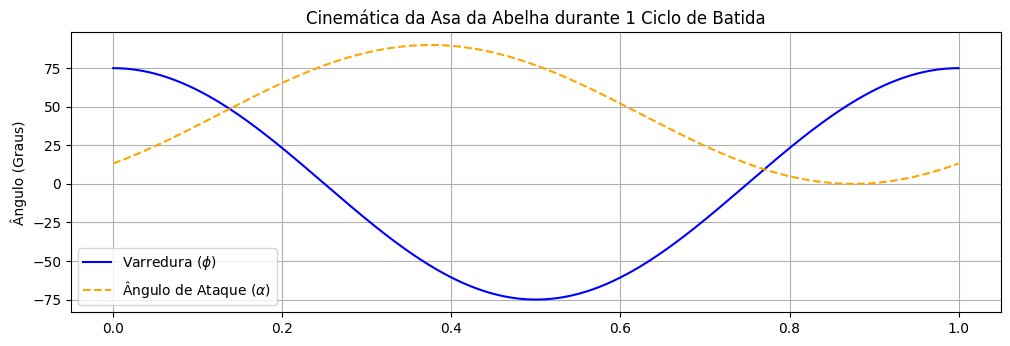

In [6]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t/T, np.degrees(phi), label=r'Varredura ($\phi$)', color='blue')
plt.plot(t/T, np.degrees(alpha), label=r'Ângulo de Ataque ($\alpha$)', color='orange', linestyle='--')
plt.title('Cinemática da Asa da Abelha durante 1 Ciclo de Batida')
plt.ylabel('Ângulo (Graus)')
plt.legend()
plt.grid(True)

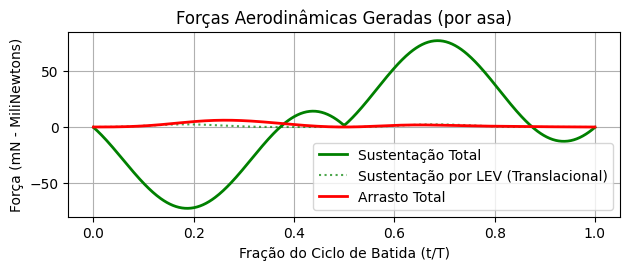

In [7]:
plt.subplot(2, 1, 2)
plt.plot(t/T, Sustentacao_Total * 1e3, label='Sustentação Total', color='green', linewidth=2)
plt.plot(t/T, L_trans * 1e3, label='Sustentação por LEV (Translacional)', color='green', linestyle=':', alpha=0.7)
plt.plot(t/T, Arrasto_Total * 1e3, label='Arrasto Total', color='red', linewidth=2)
plt.title('Forças Aerodinâmicas Geradas (por asa)')
plt.xlabel('Fração do Ciclo de Batida (t/T)')
plt.ylabel('Força (mN - MiliNewtons)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

$\quad$O pico de sustentação ocorre no meio do ciclo ($t/T = 0.25$ e $0.75$), quando a velocidade da asa é máxima. Devido à equação do LEV, a abelha atinge coeficientes de sustentação muito maiores do que qualquer avião comercial conseguiria sem cair.

$\quad$Por fim, faz-se uma verificação física, a fim de analisar se a sustentação é suficiente para que a abelha voe e não despenque devido ao seu próprio peso.

In [8]:
peso_abelha_newtons = 1e-4 * 9.81 # uma abelha pesa aprox. 100 mg (1e-4 kg) -> ~0.00098 N ou 0.98 mN
sustentacao_media = np.mean(Sustentacao_Total) * 2 * 1e3 # x 2 asas, em mN

print(f"ANÁLISE FÍSICA DO VOO")
print(f"Sustentação média gerada pelo par de asas: {sustentacao_media:.2f} mN")
print(f"Peso aproximado da abelha para pairar: {peso_abelha_newtons * 1e3:.2f} mN")
if sustentacao_media >= (peso_abelha_newtons * 1e3):
    print("Resultado: A ABELHA VOOU!!! :)")
else:
    print("Resultado: Sustentação insuficiente, a abelha caiu :(. Ajuste a amplitude espacial ou o ângulo de ataque.")

ANÁLISE FÍSICA DO VOO
Sustentação média gerada pelo par de asas: 2.09 mN
Peso aproximado da abelha para pairar: 0.98 mN
Resultado: A ABELHA VOOU!!! :)


## 4. Conclusão

$\quad$Neste `Notebook`, foi implementado com sucesso um modelo computacional capaz de estimar as forças aerodinâmicas geradas ao longo do ciclo de batimento das asas. Os resultados mostraram que a sustentação varia periodicamente no tempo e depende fortemente de parâmetros como frequência de batimento, amplitude angular e ângulo de ataque. A análise física indicou que pequenas alterações nesses parâmetros podem aumentar significativamente a sustentação média produzida.

$\quad$Apesar de ser bastante simplificado, o modelo foi capaz de reproduzir muito bem os mecanismos responsáveis pelo voo de insetos. Isso demonstra que modelos simplificados podem fornecer informações valiosas sobre fenômenos complexos, servindo como ferramenta de estudo e visualização.

$\quad$Por fim, conclui-se que o famoso mito de que "a abelha não deveria conseguir voar" surge da aplicação inadequada de modelos desenvolvidos para aeronaves convencionais. Quando os mecanismos aerodinâmicos específicos do voo de insetos são considerados, especialmente a formação do LEV, o voo da abelha torna-se não apenas possível, mas perfeitamente explicável à luz da física para.

$\quad$É justo dizer, ainda, que este `Notebook` obteve grande sucesso na missão de trazer um olhar físico às trivialidades da vida cotidiana, uma vez que "Bee Movie" foi essencial para motivar alunas do PET-Física a continuar estudando e enxergando a beleza que a física tem e que está em todas as coisas.

## Referências
1] Art_014_PET_2026.pdf. Aerodinâmica do voo das Abelhas - Uma discussão do filme “Bee Movie”. https://drive.google.com/file/d/1JgsA7Loj9D6TJcUrQqmw2hYdIRQulHQR/view

[2] ALTSHULER, D. L. et al. Short-amplitude high-frequency wing strokes determine the aerodynamics of honeybee flight. Proceedings of the National Academy of Sciences, v. 102, n. 50, p. 18213-18218, 2005.

[3] SANE, Sanjay P. The aerodynamics of insect flight. Journal of Experimental Biology, v. 206, n. 23, p. 4191-4208, 2003.

[4] SANE, Sanjay P.; DICKINSON, Michael H. The aerodynamic effects of wing rotation and a revised quasi-steady model of flapping flight. Journal of Experimental Biology, v. 205, n. 8, p. 1087-1096, 2002.

[5] Savage, N. Aerodynamics: Vortices and robobees. Nature 521, S64–S65 (2015). https://doi.org/10.1038/521S64a

[6] Newman, Mark. 2013. Computational Physics. 1 ed.